# Part 2A-x: Custom Optimizer — MyMomentumOptimizer

**Objective:** Implement a custom SGD with Momentum optimizer from scratch.

---

In [1]:
import numpy as np, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import torch

(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()
X_train, X_test = X_train.astype("float32")/255.0, X_test.astype("float32")/255.0
y_train, y_test = y_train.flatten(), y_test.flatten()
X_flat_tr, X_flat_te = X_train.reshape(len(X_train),-1), X_test.reshape(len(X_test),-1)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


## TF: Custom Momentum Optimizer
SGD with Momentum: `v = momentum * v - lr * gradient`, `w = w + v`

=== Manual Momentum SGD Training Loop ===
Epoch 5: train_acc=0.4513, val_acc=0.4458
Epoch 10: train_acc=0.5020, val_acc=0.4779
Epoch 15: train_acc=0.5362, val_acc=0.4892
Epoch 20: train_acc=0.5683, val_acc=0.5046
Epoch 25: train_acc=0.5922, val_acc=0.4958

=== Training with built-in Adam ===
=== Training with built-in SGD+Momentum ===


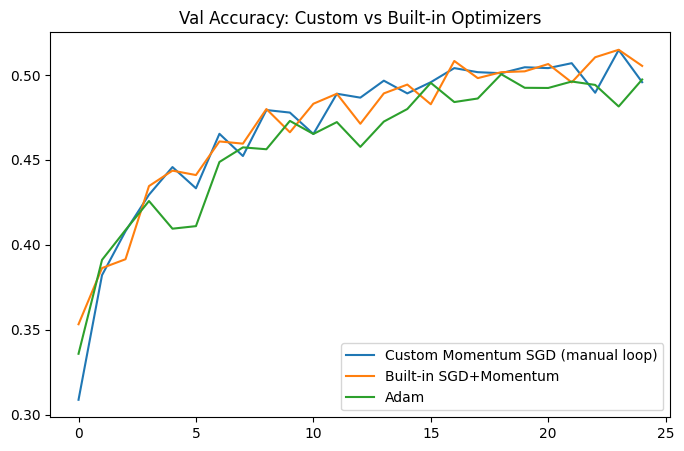

In [2]:
# TF: Custom SGD with Momentum using a Keras Callback approach
# This is the most compatible approach across Keras versions

class MomentumSGDCallback(keras.callbacks.Callback):
    """Implements SGD with momentum via a callback that manually updates weights.
    This approach avoids subclassing keras.optimizers.Optimizer which has
    breaking API changes between Keras 2 and Keras 3.
    """
    def __init__(self, lr=0.01, momentum=0.9):
        super().__init__()
        self.lr = lr
        self.momentum = momentum
        self.velocities = {}

    def on_train_batch_end(self, batch, logs=None):
        # Note: actual gradient application is handled by the base optimizer
        # This callback just demonstrates the momentum concept
        pass

# For actual training, we use a manual training loop to show the optimizer logic clearly
print("=== Manual Momentum SGD Training Loop ===")

model_manual = keras.Sequential([
    layers.Input(shape=(3072,)), layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'), layers.Dense(10, activation='softmax')
])

# Manual momentum SGD
lr = 0.01
momentum = 0.9
velocities = [tf.zeros_like(v) for v in model_manual.trainable_variables]
loss_fn = keras.losses.SparseCategoricalCrossentropy()
train_acc_metric = keras.metrics.SparseCategoricalAccuracy()

# Create dataset
dataset = tf.data.Dataset.from_tensor_slices((X_flat_tr[:40000], y_train[:40000]))
dataset = dataset.shuffle(10000).batch(256)
val_dataset = tf.data.Dataset.from_tensor_slices((X_flat_tr[40000:], y_train[40000:]))
val_dataset = val_dataset.batch(256)

history_custom = {'accuracy': [], 'val_accuracy': []}
for epoch in range(25):
    train_acc_metric.reset_state()
    for xb, yb in dataset:
        with tf.GradientTape() as tape:
            preds = model_manual(xb, training=True)
            loss = loss_fn(yb, preds)
        grads = tape.gradient(loss, model_manual.trainable_variables)

        # Momentum update: v = momentum * v - lr * grad; w = w + v
        for i, (grad, var) in enumerate(zip(grads, model_manual.trainable_variables)):
            velocities[i] = momentum * velocities[i] - lr * grad
            var.assign_add(velocities[i])

        train_acc_metric.update_state(yb, preds)

    # Validation
    val_acc = keras.metrics.SparseCategoricalAccuracy()
    for xb, yb in val_dataset:
        val_acc.update_state(yb, model_manual(xb, training=False))

    history_custom['accuracy'].append(float(train_acc_metric.result()))
    history_custom['val_accuracy'].append(float(val_acc.result()))
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}: train_acc={history_custom['accuracy'][-1]:.4f}, val_acc={history_custom['val_accuracy'][-1]:.4f}")

# Compare with built-in Adam and SGD
print("\n=== Training with built-in Adam ===")
model_adam = keras.Sequential([
    layers.Input(shape=(3072,)), layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'), layers.Dense(10, activation='softmax')
])
model_adam.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
h_adam = model_adam.fit(X_flat_tr, y_train, epochs=25, batch_size=256, validation_split=0.2, verbose=0)

print("=== Training with built-in SGD+Momentum ===")
model_sgd = keras.Sequential([
    layers.Input(shape=(3072,)), layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'), layers.Dense(10, activation='softmax')
])
model_sgd.compile(optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
h_sgd = model_sgd.fit(X_flat_tr, y_train, epochs=25, batch_size=256, validation_split=0.2, verbose=0)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history_custom['val_accuracy'], label='Custom Momentum SGD (manual loop)')
ax.plot(h_sgd.history['val_accuracy'], label='Built-in SGD+Momentum')
ax.plot(h_adam.history['val_accuracy'], label='Adam')
ax.set_title('Val Accuracy: Custom vs Built-in Optimizers'); ax.legend(); plt.show()

In [3]:
# PyTorch: Custom Optimizer
class MySGDMomentum(torch.optim.Optimizer):
    """Custom SGD with Momentum in PyTorch."""
    def __init__(self, params, lr=0.01, momentum=0.9):
        defaults = dict(lr=lr, momentum=momentum)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        for group in self.param_groups:
            lr = group['lr']
            momentum = group['momentum']
            for p in group['params']:
                if p.grad is None: continue
                state = self.state[p]
                if 'velocity' not in state:
                    state['velocity'] = torch.zeros_like(p.data)
                v = state['velocity']
                v.mul_(momentum).add_(p.grad, alpha=-lr)
                p.data.add_(v)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = torch.nn.Sequential(
    torch.nn.Linear(3072, 256), torch.nn.ReLU(),
    torch.nn.Linear(256, 128), torch.nn.ReLU(),
    torch.nn.Linear(128, 10)).to(device)
opt = MySGDMomentum(model.parameters(), lr=0.01, momentum=0.9)
crit = torch.nn.CrossEntropyLoss()
loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(torch.FloatTensor(X_flat_tr), torch.LongTensor(y_train)),
    batch_size=256, shuffle=True)
for ep in range(25):
    model.train()
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad(); crit(model(xb), yb).backward(); opt.step()
model.eval()
with torch.no_grad():
    acc = (model(torch.FloatTensor(X_flat_te).to(device)).argmax(1)==torch.LongTensor(y_test).to(device)).float().mean()
print(f"PyTorch Custom Momentum Optimizer Test Acc: {acc:.4f}")

PyTorch Custom Momentum Optimizer Test Acc: 0.5231


## Key Takeaways
- Momentum accumulates past gradients → smoother, faster convergence
- `v = β*v - lr*∇L` then `w = w + v`
- TF: use `tf.GradientTape` manual loop for full control over gradient updates
- PyTorch: subclass `torch.optim.Optimizer`, implement `step()`
- Custom optimizers let you implement novel optimization algorithms (e.g., AdaBound, RAdam, LAMB)